In [2]:
# 导入必要的库
import os.path as op
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
from copy import deepcopy
import numpy as np

In [3]:
# 设置路径和被试列表
sub_ids = ['001', '021', '022', '024', '047', '049', '051', '071', '072', '073', '076', '092']
data_path = r'.\data\1raw_rename\\'

# 选择一个被试进行测试
sub_id = sub_ids[3]  # 测试被试 001

In [4]:
# 读取数据
fname = op.join(data_path + sub_id + '_raw.fif')
raw = mne.io.read_raw_fif(fname, preload=True, verbose=None)

print(f'被试 {sub_id}:')
print(f'  通道数: {len(raw.ch_names)}')
print(f'  采样率: {raw.info["sfreq"]} Hz')
print(f'  时长: {raw.times[-1]:.2f} 秒')

# 检查并打印 F9 通道信息
if 'F9' in raw.ch_names:
    f9_idx = raw.ch_names.index('F9')
    print(f'\nF9 通道信息:')
    print(f'  通道索引: {f9_idx}')
    print(f'  通道类型: {raw.get_channel_types()[f9_idx]}')
    
    # 设置为 EOG 类型
    raw.set_channel_types(mapping={'F9': 'eog'})
    print(f'  设置后类型: {raw.get_channel_types()[f9_idx]}')
    print('✓ 已设置 F9 为 EOG 通道')
else:
    print('\n⚠ 未找到 F9 通道')

Opening raw data file .\data\1raw_rename\\024_raw.fif...
Isotrak not found
    Range : 0 ... 153549 =      0.000 ...   307.098 secs
Ready.
Reading 0 ... 153549  =      0.000 ...   307.098 secs...
被试 024:
  通道数: 63
  采样率: 500.0 Hz
  时长: 307.10 秒

F9 通道信息:
  通道索引: 4
  通道类型: eeg
  设置后类型: eog
✓ 已设置 F9 为 EOG 通道


In [15]:
# 检查 montage 信息
print('\nMontage 信息:')
if raw.info['dig'] is not None:
    print(f'  已有 montage: {len(raw.info["dig"])} 个数字化点')
    # 可视化电极位置
    raw.plot_sensors(show_names=True)
else:
    print('  ⚠ 未找到 montage 信息')


Montage 信息:
  已有 montage: 66 个数字化点


In [16]:
# 移除边缘电极（容易受伪迹影响），保留 F9 用作 EOG
channels_to_drop = ['P9', 'F10', 'P10']
existing_channels = [ch for ch in channels_to_drop if ch in raw.ch_names]

if existing_channels:
    raw.drop_channels(existing_channels)
    print(f'✓ 已移除电极: {existing_channels}')
    print(f'  剩余通道数: {len(raw.ch_names)}')
else:
    print('⚠ 未找到需要移除的电极')

✓ 已移除电极: ['P9', 'F10', 'P10']
  剩余通道数: 60


## 步骤 1: 标记坏导 (Bad Channels)

手动检查数据，标记有问题的通道

In [29]:
# 可视化检查数据，手动标记坏导
%matplotlib qt
raw.plot(n_channels=50, duration=40, scalings=60e-6, remove_dc=True,)

# 标记完成后，查看坏导列表
print(f'坏导: {raw.info["bads"]}')

坏导: ['AFz', 'F1', 'FCz', 'F3']


In [24]:
# 保存标记了坏导的数据
save_path_bad = r'.\data\2raw_bad\\'
import os
os.makedirs(save_path_bad, exist_ok=True)
raw.save(save_path_bad + sub_id + '_raw.fif', overwrite=True)
print(f'✓ 已保存到: {save_path_bad}{sub_id}_raw.fif')

Overwriting existing file.
Writing D:\LYW\REST_COM\preprocessing\data\2raw_bad\001_raw.fif
Closing D:\LYW\REST_COM\preprocessing\data\2raw_bad\001_raw.fif
[done]
✓ 已保存到: .\data\2raw_bad\\001_raw.fif


In [25]:
# 插值、滤波、重参考（合并处理）
original_bads = deepcopy(raw.info['bads'])
print(f'坏导: {original_bads}')

# 插值坏导
raw_interp = raw.copy().interpolate_bads(reset_bads=True)
print(f'插值后坏导: {raw_interp.info["bads"]}')

# 带通滤波 0.1-40 Hz
raw_filtered = raw_interp.copy().filter(0.1, 40.)

# 陷波滤波 50Hz 及其倍频
sample_rate = int(raw_filtered.info['sfreq'])
freqs = np.arange(50, sample_rate / 2, 50)
raw_notch = raw_filtered.copy().notch_filter(freqs=freqs)

# 重参考（平均参考）
raw_rerefer = raw_notch.copy().set_eeg_reference(ref_channels='average')

print(f'✓ 预处理完成（插值 → 滤波 → 重参考）')

坏导: ['AFz', 'F1', 'FCz', 'F3']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 55 sensor positions
Interpolating 4 sensors
插值后坏导: []
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
✓ 预处理完成（插值 → 滤波 → 重参考）


## 步骤 5: ICA 去除眼电伪迹

In [26]:
# ICA 训练（使用 1Hz 高通滤波的数据）
import time
time_start = time.time()

raw_filt = raw_rerefer.copy()
raw_filt.load_data().filter(l_freq=1., h_freq=None)

ica = ICA(n_components=50, random_state=97, max_iter=500)
ica.fit(raw_filt)

time_end = time.time()
print(f'✓ ICA 训练完成，耗时: {time_end - time_start:.2f} 秒')

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 50 components
Fitting ICA took 27.3s.
✓ ICA 训练完成，耗时: 27.69 秒


Using EOG channel: F9
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

自动检测到的眼电成分: [12, 25]


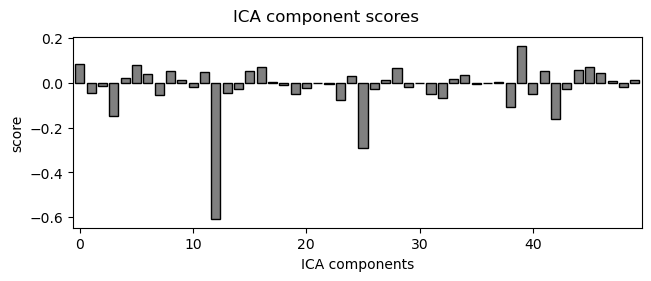

In [27]:
# 自动检测眼电成分
eog_inds, eog_scores = ica.find_bads_eog(raw_filt, threshold=3.0)
print(f'自动检测到的眼电成分: {eog_inds}')

# 可视化眼电成分得分
ica.plot_scores(eog_scores)

In [28]:
# 可视化所有 ICA 成分（手动检查）
ica.plot_components(inst=raw_filt)

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x496 with 10 Axes>]

In [30]:
# 手动修改眼电成分（如果自动检测不准确）
# 方法1: 直接指定成分编号
eog_inds = [12]  # 例如：手动指定 ICA000 和 ICA001 为眼电成分

print(f'最终使用的眼电成分: {eog_inds}')

最终使用的眼电成分: [12]


In [31]:
# 应用 ICA 去除眼电成分
ica.exclude = eog_inds
reconst_raw = raw_filt.copy()
ica.apply(reconst_raw)
print(f'✓ 已去除眼电成分: {ica.exclude}')

Applying ICA to Raw instance
    Transforming to ICA space (50 components)
    Zeroing out 1 ICA component
    Projecting back using 59 PCA components
✓ 已去除眼电成分: [12]


In [32]:
# 保存 ICA 结果
save_path_ica = r'.\data\4raw_ica\\'
os.makedirs(save_path_ica, exist_ok=True)

# 保存 ICA 模型
ica.save(save_path_ica + sub_id + '_ica.fif')

# 保存去除眼电后的数据
reconst_raw.save(save_path_ica + sub_id + '_raw.fif', overwrite=True)
print(f'✓ 已保存 ICA 模型和处理后数据到: {save_path_ica}')

Writing ICA solution to D:\LYW\REST_COM\preprocessing\data\4raw_ica\001_ica.fif...
Writing D:\LYW\REST_COM\preprocessing\data\4raw_ica\001_raw.fif
Closing D:\LYW\REST_COM\preprocessing\data\4raw_ica\001_raw.fif
[done]
✓ 已保存 ICA 模型和处理后数据到: .\data\4raw_ica\\


---
## 批量处理所有被试 - 看对应的 batch_preprocessing.py